# **LAB 3: BINARY CLASSIFICATION WITH NEURAL NETWORKS**
# Shishir Pandeya (ACE079BCT062)

# Neural Network:

A neural network is a type of machine learning model inspired by how the human brain works. It learns patterns from data by using layers of connected units called neurons.

## 1. Data Retrieval and Inspection
We import the library pandas and load the csv data file

In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Data retrieval & inspection
# Load CSV with pandas
df = pd.read_csv("circles_binary_classification.csv")

# Show head and describe
print(df.head())
print(df.describe())

         X1        X2  label
0  0.754246  0.231481      1
1 -0.756159  0.153259      1
2 -0.815392  0.173282      1
3 -0.393731  0.692883      1
4  0.442208 -0.896723      0
                X1           X2       label
count  1000.000000  1000.000000  1000.00000
mean     -0.000448    -0.000804     0.50000
std       0.639837     0.641156     0.50025
min      -1.059502    -1.067768     0.00000
25%      -0.619251    -0.612176     0.00000
50%       0.008762    -0.003949     0.50000
75%       0.621933     0.624822     1.00000
max       1.033712     1.036004     1.00000


## 2. Data cleaning & feature design:
We convert the data into NumPy arrays and then into PyTorch tensors.

In [2]:
# 2. Data cleaning & feature design
# Create X and y
X = df[['X1', 'X2']].values
y = df['label'].values

# Convert to torch tensors with correct dtypes (float32 is standard for PyTorch)
X = torch.from_numpy(X.copy()).type(torch.float32)
y = torch.from_numpy(y.copy()).type(torch.float32)

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: torch.Size([1000, 2]), y shape: torch.Size([1000])


## 3. Visualize Data
We are plotting the data points to see the pattern. We observed two concentric circles, which confirms the data is not linearly separable (a straight line can't separate them).

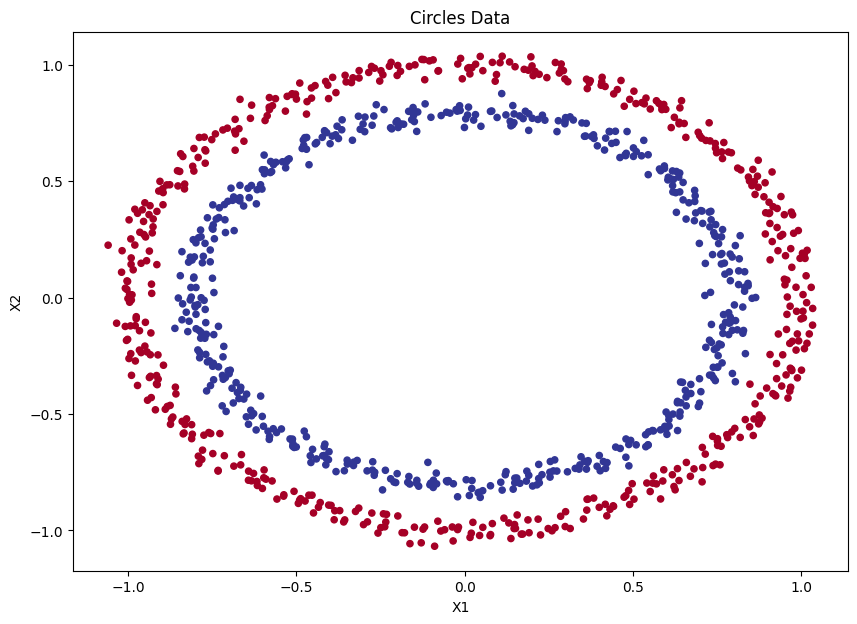

In [3]:
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, s=20)
plt.title("Circles Data")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

## 4. Train/Test Split:
We are splitting the data 80/20. We train on the 80% and test on the unseen 20% to check if the model actually "learned" or just memorized.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 800, Test size: 200


## 5. Device and Dtype:
We are setting up code to run on GPU (cuda) if available for speed, otherwise CPU.

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Move data to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

Using device: cpu


## 6. Implement baseline models:
We are defining the three network architectures.

V0 & V1: Linear layers only (mathematically just straight lines).

V2: Adds ReLU activation (allows the model to learn curves/shapes).

In [6]:
# Model V0: 2 -> 5 -> 1 (Linear only)
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 5)
        self.layer_2 = nn.Linear(5, 1)
    def forward(self, x):
        return self.layer_2(self.layer_1(x))

# Model V1: 2 -> 15 -> 15 -> 1 (Deep Linear)
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 15)
        self.layer_2 = nn.Linear(15, 15)
        self.layer_3 = nn.Linear(15, 1)
    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))

# Model V2: 2 -> 64 -> 64 -> 10 -> 1 (With ReLU)
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 64)
        self.layer_2 = nn.Linear(64, 64)
        self.layer_3 = nn.Linear(64, 10)
        self.layer_4 = nn.Linear(10, 1)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.relu(self.layer_3(x))
        return self.layer_4(x)

## 7. Training Loop, Predictions & Evaluation:

Helper Functions: accuracy_fn calculates % correct. plot_decision_boundary visualizes what the model "thinks".

Training Function: A reusable loop that handles the Forward Pass -> Loss Calculation -> Backpropagation -> Optimizer Step.

Execution: We train all 3 models and plot their decision boundaries.


--- Training V0 (Linear) ---
Epoch 0 | Loss: 0.6957 | Acc: 50.00%


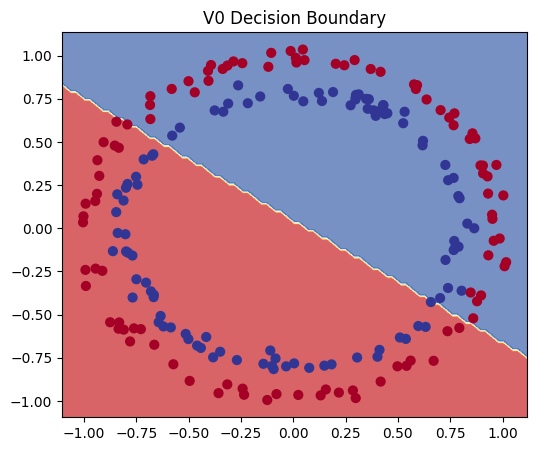


--- Training V1 (Deep Linear) ---
Epoch 0 | Loss: 0.6959 | Acc: 50.00%
Epoch 100 | Loss: 0.6930 | Acc: 51.25%
Epoch 200 | Loss: 0.6930 | Acc: 51.62%
Epoch 300 | Loss: 0.6930 | Acc: 51.12%
Epoch 400 | Loss: 0.6930 | Acc: 51.00%
Epoch 500 | Loss: 0.6930 | Acc: 51.00%
Epoch 600 | Loss: 0.6930 | Acc: 51.00%
Epoch 700 | Loss: 0.6930 | Acc: 51.00%
Epoch 800 | Loss: 0.6930 | Acc: 51.00%
Epoch 900 | Loss: 0.6930 | Acc: 51.00%


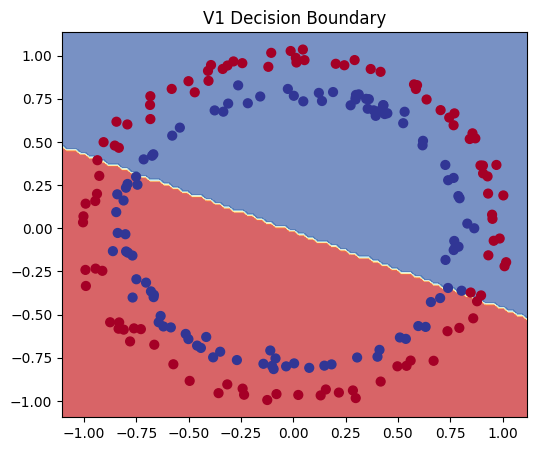


--- Training V2 (ReLU) ---
Epoch 0 | Loss: 0.6962 | Acc: 50.00%
Epoch 100 | Loss: 0.6881 | Acc: 57.12%
Epoch 200 | Loss: 0.6802 | Acc: 67.88%
Epoch 300 | Loss: 0.6588 | Acc: 80.88%
Epoch 400 | Loss: 0.5649 | Acc: 98.00%
Epoch 500 | Loss: 0.4674 | Acc: 65.62%
Epoch 600 | Loss: 0.3337 | Acc: 82.62%
Epoch 700 | Loss: 0.0516 | Acc: 100.00%
Epoch 800 | Loss: 0.0224 | Acc: 100.00%
Epoch 900 | Loss: 0.0135 | Acc: 100.00%


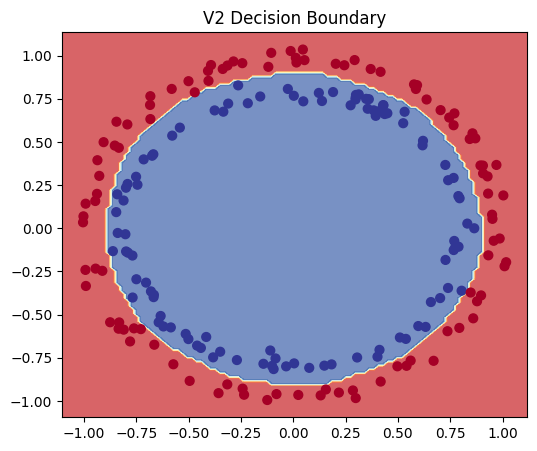

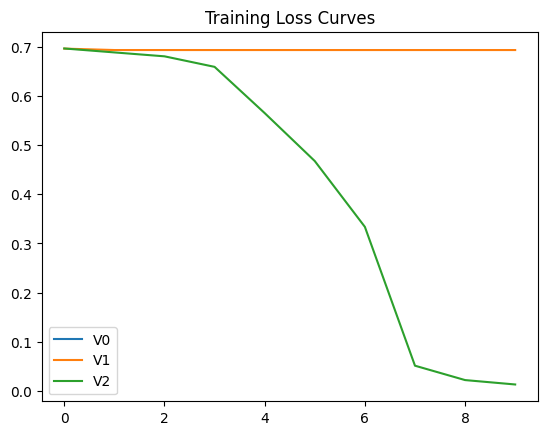

In [7]:
# --- Helper Functions ---
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

def plot_decision_boundary(model, X, y):
    # Move to CPU for plotting
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))
    X_pred = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    model.eval()
    with torch.inference_mode():
        y_logits = model(X_pred)
    
    y_pred = torch.round(torch.sigmoid(y_logits)).reshape(xx.shape).detach().numpy()
    
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

# --- Main Training Function ---
def train_experiment(model_class, epochs, name):
    torch.manual_seed(42)
    model = model_class().to(device)
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    print(f"\n--- Training {name} ---")
    loss_curve = []

    for epoch in range(epochs):
        model.train()
        
        # 1. Forward pass
        y_logits = model(X_train).squeeze()
        y_pred = torch.round(torch.sigmoid(y_logits))
        
        # 2. Loss & Acc
        loss = loss_fn(y_logits, y_train)
        acc = accuracy_fn(y_train, y_pred)
        
        # 3. Optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            loss_curve.append(loss.item())
            print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}%")
            
    return model, loss_curve

# --- Execute Experiments ---

# 1. Model V0
model_0, loss_0 = train_experiment(CircleModelV0, epochs=100, name="V0 (Linear)")
plt.figure(figsize=(6, 5))
plt.title("V0 Decision Boundary")
plot_decision_boundary(model_0, X_test, y_test)
plt.show()

# 2. Model V1
model_1, loss_1 = train_experiment(CircleModelV1, epochs=1000, name="V1 (Deep Linear)")
plt.figure(figsize=(6, 5))
plt.title("V1 Decision Boundary")
plot_decision_boundary(model_1, X_test, y_test)
plt.show()

# 3. Model V2
model_2, loss_2 = train_experiment(CircleModelV2, epochs=1000, name="V2 (ReLU)")
plt.figure(figsize=(6, 5))
plt.title("V2 Decision Boundary")
plot_decision_boundary(model_2, X_test, y_test)
plt.show()

# 4. Compare Loss Curves
plt.plot(loss_0, label="V0")
plt.plot(loss_1, label="V1")
plt.plot(loss_2, label="V2")
plt.title("Training Loss Curves")
plt.legend()
plt.show()

## 8. Discussion and Conclusion:

### Summary:

**V0 (Linear):** This model failed as it draws a straight line, which cannot separate concentric circles. The accuracy of model was found to be approximately ~50%.

**V1 (Deep Linear):** The model also failed the accuracy test as even with more layers, without activation functions, the math collapses into a single linear transformation. The accuracy of the model was found to be approximately ~50%.

**V2 (ReLU):** The model achieved a very high accuracy (accuracy > 99%) . The ReLU activation introduced non-linearity, allowing the model to learn the curved "circle" shape.

### Conclusion:

By implementing and analyzing three different neural network architectures on the concentric circles dataset, we found that linear models regardless of depth failed to converge, achieving only ~50% accuracy because they could not separate non-linear data. However, by introducing the ReLU activation function in Model V2, the network successfully learned the curved decision boundary and achieved >99% accuracy.  This confirms that non-linear activation functions are essential for neural networks to approximate complex geometric patterns that a simple stack of linear layers cannot.

==============================================================================================

## Extra Credit:
We are re-training the successful Model V2 (ReLU) using the Adam optimizer instead of SGD. We then plot the loss curves of both optimizers on the same graph to see which one learns faster.

**SGD (Stochastic Gradient Descent):** Updates weights using a fixed learning rate. It can be slow.

**Adam (Adaptive Moment Estimation):** Adjusts the learning rate for each parameter individually and remembers previous updates. It usually converges much faster.


--- Training Model V2 with Adam ---
Epoch 0 | Loss: 0.6962
Epoch 100 | Loss: 0.0007
Epoch 200 | Loss: 0.0003
Epoch 300 | Loss: 0.0002
Epoch 400 | Loss: 0.0001
Epoch 500 | Loss: 0.0001
Epoch 600 | Loss: 0.0001
Epoch 700 | Loss: 0.0000
Epoch 800 | Loss: 0.0000
Epoch 900 | Loss: 0.0000


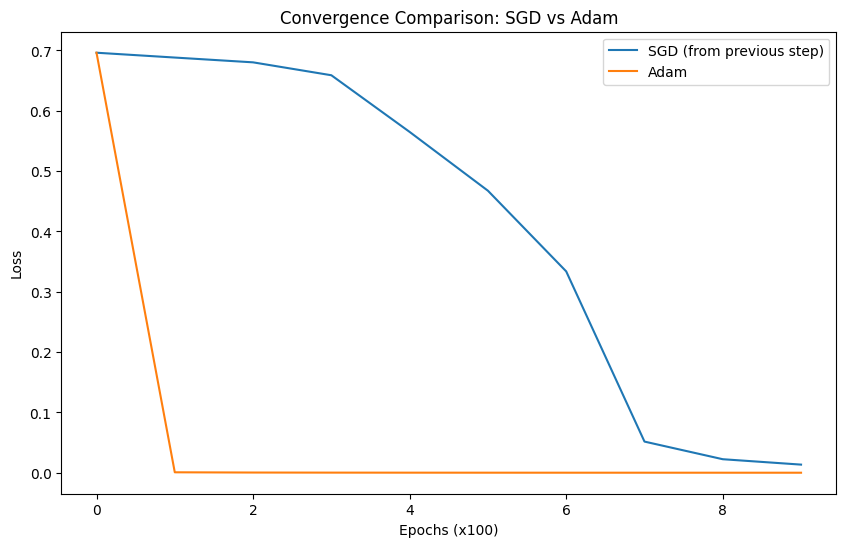

In [8]:
# --- Extra Credit: Train with Adam ---
torch.manual_seed(42)

# 1. Re-create the model (start fresh)
model_adam = CircleModelV2().to(device)

# 2. Setup Loss and Adam Optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.01) # Adam often works well with lower LR than SGD

# 3. Training Loop for Adam
print("\n--- Training Model V2 with Adam ---")
loss_curve_adam = []

for epoch in range(1000):
    model_adam.train()
    
    # Forward pass
    y_logits = model_adam(X_train).squeeze()
    loss = loss_fn(y_logits, y_train)
    
    # Optimize
    optimizer_adam.zero_grad()
    loss.backward()
    optimizer_adam.step()
    
    if epoch % 100 == 0:
        loss_curve_adam.append(loss.item())
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

# --- Compare SGD vs Adam ---
plt.figure(figsize=(10, 6))
plt.plot(loss_2, label="SGD (from previous step)")
plt.plot(loss_curve_adam, label="Adam")
plt.title("Convergence Comparison: SGD vs Adam")
plt.xlabel("Epochs (x100)")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Analysis of Results:
By comparing the loss curves, we found that the Adam optimizer converged significantly faster than SGD. While SGD's loss decreased gradually over 1000 epochs, Adam's loss dropped sharply within the first 100 epochs and stabilized quickly.  This confirms that Adam's adaptive learning rates and momentum make it far more efficient for training neural networks on this type of data compared to standard SGD.